# AQI Model Prediction

This notebook loads the finalized AQI forecasting model and applies the exact feature schema used during training.

The notebook verifies that:

- the trained model can be loaded successfully,
- the saved feature schema is preserved,
- historical observations can be passed through the model,
- predictions are generated without feature mismatch,
- actual and predicted AQI can be compared,
- and a single new observation can be used for inference.

The prediction pipeline uses the same feature engineering structure established during model training.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load Trained Model and Feature Schema

The model artifact and feature schema are loaded from the models directory.

The feature schema is treated as the source of truth for inference so that the prediction pipeline uses exactly the same predictors as the training pipeline.

In [2]:
MODEL_PATH = "../models/aqi_model.pkl"
FEATURE_PATH = "../models/feature_columns.pkl"

model = joblib.load(MODEL_PATH)
feature_columns = joblib.load(FEATURE_PATH)

print("Model loaded successfully.")
print("Model type:", type(model).__name__)

print("\nExpected number of features:", len(feature_columns))
print("Expected features:")
print(feature_columns)

Model loaded successfully.
Model type: RandomForestRegressor

Expected number of features: 16
Expected features:
['CO', 'NO', 'NO2', 'O3', 'SO2', 'PM2_5', 'PM10', 'NH3', 'hour', 'day', 'month', 'weekday', 'AQI', 'AQI_lag_1', 'AQI_change', 'AQI_rolling_avg']


## 2. Load Feature-Engineered Data

The same feature-engineered dataset used in the training pipeline is loaded.

Datetime is converted to pandas datetime format and observations are sorted chronologically.

In [3]:
DATA_PATH = "../data/processed/AQI_feature_engineered.csv"

df = pd.read_csv(DATA_PATH)

df["datetime"] = pd.to_datetime(
    df["datetime"],
    errors="coerce"
)

df = df.sort_values("datetime").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Date range:")
print(df["datetime"].min(), "to", df["datetime"].max())

display(df.head())

Dataset shape: (120, 17)
Date range:
2026-08-30 03:00:00 to 2026-09-04 02:00:00


,datetime,AQI,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3,hour,day,month,weekday,AQI_lag_1,AQI_change,AQI_rolling_avg
0,2026-08-30 03:00:00,2,70.64,0.05,1.18,35.02,0.90,6.99,20.53,0.00,3,30,8,6,NaN,0.0,2.000000
1,2026-08-30 04:00:00,1,71.37,0.13,1.16,36.15,0.96,6.50,18.09,0.00,4,30,8,6,2.0,-1.0,2.000000
2,2026-08-30 05:00:00,1,71.14,0.17,0.98,38.45,0.94,6.11,15.69,0.00,5,30,8,6,1.0,0.0,1.500000
3,2026-08-30 06:00:00,1,70.22,0.16,0.77,41.43,0.91,6.07,14.75,0.01,6,30,8,6,1.0,0.0,1.333333
4,2026-08-30 07:00:00,1,70.41,0.11,0.71,43.64,0.87,6.01,15.01,0.00,7,30,8,6,1.0,0.0,1.000000


## 3. Reconstruct the Forecasting Target

The trained model predicts the next available AQI observation.

Therefore, the same target construction used during training is reproduced here:

AQI_future = AQI shifted by one observation.

This keeps inference and evaluation consistent with the training formulation.

In [4]:
df["AQI_future"] = df["AQI"].shift(-1)

print("Total observations:", len(df))
print("Valid future targets:", df["AQI_future"].notna().sum())
print("Missing future targets:", df["AQI_future"].isna().sum())

Total observations: 120
Valid future targets: 119
Missing future targets: 1


## 4. Validate Feature Schema

Before prediction, the notebook verifies that every feature expected by the saved model exists in the current dataset.

This prevents silent feature mismatch between model training and deployment.

In [5]:
missing_features = [
    col for col in feature_columns
    if col not in df.columns
]

if missing_features:
    raise ValueError(
        f"Missing required model features: {missing_features}"
    )

print("Feature schema validation passed.")
print("All required features are available.")

Feature schema validation passed.
All required features are available.


## 5. Prepare Prediction Features

Only the features stored in the trained model's feature schema are selected.

No new encoding, scaling, column reordering, or feature creation is performed here because the training pipeline already defines the required representation.

In [6]:
X_prediction = df[feature_columns].copy()

print("Prediction feature shape:", X_prediction.shape)

print("\nPrediction feature columns:")
print(X_prediction.columns.tolist())

print("\nMissing values:")
print(X_prediction.isna().sum())

Prediction feature shape: (120, 16)

Prediction feature columns:
['CO', 'NO', 'NO2', 'O3', 'SO2', 'PM2_5', 'PM10', 'NH3', 'hour', 'day', 'month', 'weekday', 'AQI', 'AQI_lag_1', 'AQI_change', 'AQI_rolling_avg']

Missing values:
CO                 0
NO                 0
NO2                0
O3                 0
SO2                0
PM2_5              0
PM10               0
NH3                0
hour               0
day                0
month              0
weekday            0
AQI                0
AQI_lag_1          1
AQI_change         0
AQI_rolling_avg    0
dtype: int64


## 6. Prepare Valid Historical Observations

Some engineered features depend on previous observations.

Rows containing unavailable feature values are excluded from historical evaluation. This does not modify the original dataset; it only creates a valid inference subset.

In [7]:
valid_mask = X_prediction.notna().all(axis=1)

X_valid = X_prediction.loc[valid_mask].copy()

print("Original rows:", len(X_prediction))
print("Valid prediction rows:", len(X_valid))
print("Excluded rows:", len(X_prediction) - len(X_valid))

Original rows: 120
Valid prediction rows: 119
Excluded rows: 1


## 7. Generate Historical Predictions

The saved production model is used to generate next-observation AQI predictions for all valid historical feature rows.

These predictions are inference outputs and are not used to retrain the model.

In [8]:
predictions = model.predict(X_valid)

prediction_df = df.loc[X_valid.index, [
    "datetime",
    "AQI"
]].copy()

prediction_df["Predicted_AQI"] = predictions

prediction_df["AQI_future"] = df.loc[
    X_valid.index,
    "AQI_future"
].values

prediction_df["Prediction_Error"] = (
    prediction_df["AQI_future"]
    - prediction_df["Predicted_AQI"]
)

display(prediction_df.head(10))

,datetime,AQI,Predicted_AQI,AQI_future,Prediction_Error
1,2026-08-30 04:00:00,1,1.007556,1.0,-0.007556
2,2026-08-30 05:00:00,1,1.000000,1.0,0.000000
3,2026-08-30 06:00:00,1,1.000000,1.0,0.000000
4,2026-08-30 07:00:00,1,1.000000,1.0,0.000000
5,2026-08-30 08:00:00,1,1.000000,1.0,0.000000
6,2026-08-30 09:00:00,1,1.000000,1.0,0.000000
7,2026-08-30 10:00:00,1,1.000000,1.0,0.000000
8,2026-08-30 11:00:00,1,1.000000,1.0,0.000000
9,2026-08-30 12:00:00,1,1.000000,1.0,0.000000
10,2026-08-30 13:00:00,1,1.000000,1.0,0.000000


## 8. Historical Inference Performance

The following metrics describe the predictions generated by the saved model on the available historical observations.

These values should not be interpreted as a replacement for the untouched chronological test-set evaluation from the training notebook. The official model-selection metrics remain those calculated in the model-training stage.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

evaluation_df = prediction_df.dropna(
    subset=["AQI_future", "Predicted_AQI"]
).copy()

mae = mean_absolute_error(
    evaluation_df["AQI_future"],
    evaluation_df["Predicted_AQI"]
)

rmse = np.sqrt(
    mean_squared_error(
        evaluation_df["AQI_future"],
        evaluation_df["Predicted_AQI"]
    )
)

r2 = r2_score(
    evaluation_df["AQI_future"],
    evaluation_df["Predicted_AQI"]
)

print("Historical Inference Performance")
print("-" * 40)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Historical Inference Performance
----------------------------------------
MAE  : 0.0158
RMSE : 0.0748
R²   : 0.8621


## 9. Persistence Comparison

For reference, a persistence prediction assumes that the next AQI remains equal to the current AQI.

This provides an interpretable benchmark for short-term AQI forecasting.

In [11]:
evaluation_df["Persistence_AQI"] = evaluation_df["AQI"]

persistence_mae = mean_absolute_error(
    evaluation_df["AQI_future"],
    evaluation_df["Persistence_AQI"]
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        evaluation_df["AQI_future"],
        evaluation_df["Persistence_AQI"]
    )
)

persistence_r2 = r2_score(
    evaluation_df["AQI_future"],
    evaluation_df["Persistence_AQI"]
)

print("Persistence Baseline")
print("-" * 40)
print(f"MAE  : {persistence_mae:.4f}")
print(f"RMSE : {persistence_rmse:.4f}")
print(f"R²   : {persistence_r2:.4f}")

Persistence Baseline
----------------------------------------
MAE  : 0.0169
RMSE : 0.1302
R²   : 0.5823


## 10. Actual Future AQI vs Model Prediction

The plot compares the next-observation AQI with the model's forecast across the historical inference period.

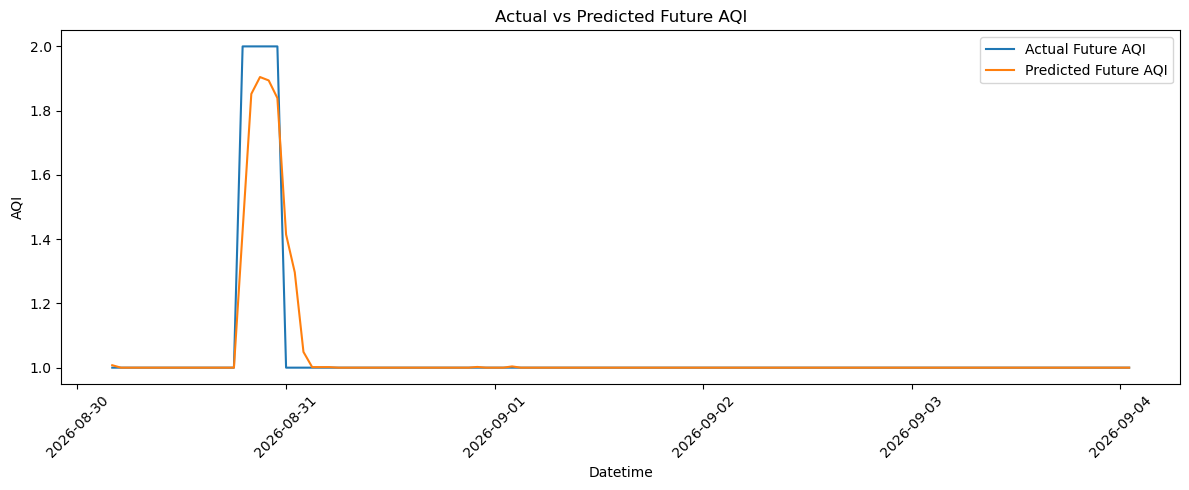

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    evaluation_df["datetime"],
    evaluation_df["AQI_future"],
    label="Actual Future AQI"
)

plt.plot(
    evaluation_df["datetime"],
    evaluation_df["Predicted_AQI"],
    label="Predicted Future AQI"
)

plt.xlabel("Datetime")
plt.ylabel("AQI")
plt.title("Actual vs Predicted Future AQI")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 11. Prediction Error Analysis

Prediction errors are examined to identify whether the model systematically overpredicts or underpredicts future AQI.

In [13]:
evaluation_df["Absolute_Error"] = (
    evaluation_df["AQI_future"]
    - evaluation_df["Predicted_AQI"]
).abs()

print("Mean Absolute Error:",
      evaluation_df["Absolute_Error"].mean())

print("Maximum Absolute Error:",
      evaluation_df["Absolute_Error"].max())

display(
    evaluation_df.sort_values(
        "Absolute_Error",
        ascending=False
    ).head(10)
)

Mean Absolute Error: 0.01579082593489372
Maximum Absolute Error: 0.5742619047619058


,datetime,AQI,Predicted_AQI,AQI_future,Prediction_Error,Persistence_AQI,Absolute_Error
16,2026-08-30 19:00:00,1,1.425738,2.0,0.574262,1,0.574262
21,2026-08-31 00:00:00,2,1.414460,1.0,-0.414460,2,0.414460
22,2026-08-31 01:00:00,1,1.296738,1.0,-0.296738,1,0.296738
20,2026-08-30 23:00:00,2,1.839063,2.0,0.160937,2,0.160937
17,2026-08-30 20:00:00,2,1.852063,2.0,0.147937,2,0.147937
19,2026-08-30 22:00:00,2,1.894063,2.0,0.105937,2,0.105937
18,2026-08-30 21:00:00,2,1.904619,2.0,0.095381,2,0.095381
23,2026-08-31 02:00:00,1,1.049000,1.0,-0.049000,1,0.049000
1,2026-08-30 04:00:00,1,1.007556,1.0,-0.007556,1,0.007556
47,2026-09-01 02:00:00,1,1.003889,1.0,-0.003889,1,0.003889


## 12. Single Observation Prediction

A single observation is constructed using the exact feature schema required by the saved model.

This simulates how the model will later receive processed features from the automated prediction pipeline.

In [14]:
sample_features = X_valid.iloc[[0]].copy()

sample_prediction = model.predict(
    sample_features
)

print("Sample prediction:")
print(f"Predicted next AQI: {sample_prediction[0]:.4f}")

Sample prediction:
Predicted next AQI: 1.0076


## 13. Final Prediction Pipeline Verification

The final verification confirms that the saved model and feature schema work together without feature mismatch.

In [15]:
assert len(feature_columns) == X_valid.shape[1]

assert list(X_valid.columns) == feature_columns

assert len(predictions) == len(X_valid)

print("Prediction pipeline verification passed.")
print("Model:", type(model).__name__)
print("Features:", len(feature_columns))
print("Prediction rows:", len(predictions))

Prediction pipeline verification passed.
Model: RandomForestRegressor
Features: 16
Prediction rows: 119


## Conclusion

The finalized AQI model was successfully loaded and used for inference using the exact feature schema established during training.

The prediction pipeline preserves the chronological forecasting formulation:

Current information → Next-observation AQI

Historical predictions are compared with the future AQI target and with a persistence baseline.

The saved model artifact is now ready for integration with the model registry, explainability workflow, Flask API, and Streamlit dashboard.